In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
import yfinance as yf
import statsmodels.api as sm
from scipy.spatial import distance

import seaborn as sns
import warnings 

plt.style.use("seaborn-v0_8")
warnings.filterwarnings("ignore") 

In [28]:
df = pd.read_excel('data/Diabetes_Data.xlsx')

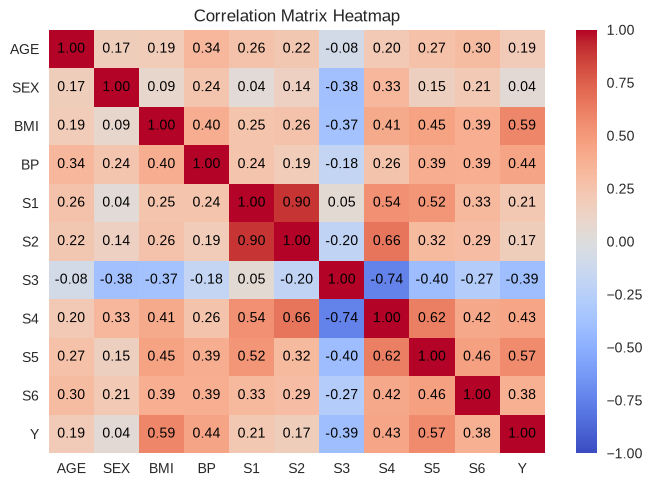

In [29]:
#1.1 Checking for correlation among explanatory variables
_, ax = plt.subplots()
matrix = df.corr()

img = ax.imshow(matrix, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(img)

ticks = np.arange(len(matrix.columns))
ax.set_xticks(ticks, labels=matrix.columns)
ax.set_yticks(ticks, labels=matrix.columns)

for i in range(len(matrix.columns)):
    for j in range(len(matrix.columns)):
        ax.text(j, i, f"{matrix.values[i, j]:.2f}", 
                ha="center", va="center", color="black")

plt.title("Correlation Matrix Heatmap")
plt.grid(False)
plt.show()

In [30]:
#1.3 Training a linear regression model
features = ['AGE', 'SEX', 'BMI', 'BP', 'S1', 'S2', 'S3', 'S4', 'S5', 'S6']
y = df['Y']
X = df[features]
X = sm.add_constant(X)

model = sm.OLS(y, X)
results = model.fit()

mse = results.mse_resid
adj_r2 = results.rsquared_adj

print(f"Mean Squared Error: {mse:.2f}")
print(f"Adjusted R^2 Score: {adj_r2:.2f}")

Mean Squared Error: 2932.68
Adjusted R^2 Score: 0.51


In [31]:
# Check feature importance
p_values = results.pvalues

# Check which variables are significant at the 0.05 level
significant_vars = p_values[p_values < 0.05]
print("Significant Variables:\n", significant_vars)

Significant Variables:
 const    1.016617e-06
SEX      1.041671e-04
BMI      4.296391e-14
BP       1.024278e-06
S5       1.555899e-05
dtype: float64


In [32]:
def forward_regression(features, y, signif_level=0.05):
    initial_features = features.columns.tolist()
    best_features = []
    while len(initial_features) > 0:
        remaining_features = list(set(initial_features) - set(best_features))
        new_pval = pd.Series(index=remaining_features, dtype='float64')
        
        for new_column in remaining_features:
            model = sm.OLS(y, sm.add_constant(features[best_features + [new_column]])).fit()
            new_pval[new_column] = model.pvalues[new_column]
        
        min_p_value = new_pval.min()
        if min_p_value < signif_level:
            best_features.append(new_pval.idxmin())
        else:
            break
            
    return best_features

In [33]:
# 1.5 Feature Selection using Sequential Feature Selector
sel_features = forward_regression(X.drop(columns='const'), y)

# View selected feature names/indices
print(f"Selected Features: {sel_features}")

# Retrain model with selected features
model_selected = sm.OLS(y, X[sel_features])
results_selected = model_selected.fit()

mse_selected = results_selected.mse_resid
adj_r2_selected = results_selected.rsquared_adj

print(f"Mean Squared Error: {mse_selected:.2f}")
print(f"Adjusted R^2 Score: {adj_r2_selected:.2f}")

Selected Features: ['BMI', 'S5', 'BP', 'S1', 'SEX', 'S2']
Mean Squared Error: 3940.52
Adjusted R^2 Score: 0.86


In [34]:
titanic_df = pd.read_csv('data/titanic3.csv')

In [35]:
# 2.2 Probability of survival
no_of_passengers = titanic_df.shape[0]
survivors = titanic_df[titanic_df['survived'] == 1]
no_of_survivors = len(survivors)
probability_of_survival = no_of_survivors / no_of_passengers
print(f"Probability of Survival: {probability_of_survival:.4f}")

Probability of Survival: 0.3820


In [36]:
#2.3 Survival probabilities
age_bins = [0, 12, 18, 35, 60, 80]
age_labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
titanic_df['age_group'] = pd.cut(titanic_df['age'], bins=age_bins, labels=age_labels)

# Create the pivot table for survival probability
survival_table = titanic_df.pivot_table(
    values='survived', 
    index=['sex', 'age_group'], 
    columns='pclass', 
    aggfunc='mean'
)

# Display the table formatted as percentages
print((survival_table * 100).round(1).astype(str) + '%')

pclass                   1       2       3
sex    age_group                          
female Child          0.0%  100.0%   46.7%
       Teen         100.0%   87.5%   60.7%
       Young Adult   98.1%   89.7%   46.5%
       Adult         96.7%   83.3%   31.8%
       Senior        83.3%     NaN  100.0%
male   Child        100.0%  100.0%   34.3%
       Teen          50.0%    0.0%    8.1%
       Young Adult   43.2%   11.2%   18.1%
       Adult         32.1%    2.4%    8.9%
       Senior         6.7%   16.7%    0.0%


In [37]:
#2.4 Traning a logistic regression model
# Preprocessing
label = LabelEncoder()
titanic_df['sex'] = label.fit_transform(titanic_df['sex'])

imputer = SimpleImputer(strategy='median')
titanic_df['age'] = imputer.fit_transform(titanic_df[['age']])

logistic_features = ['pclass','sex', 'age']
X = titanic_df[logistic_features]
y = titanic_df['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=False)
logistic_regression = LogisticRegression(random_state=0)
logistic_regression.fit(X_train, y_train)

# Parameter significance
X_with_intercept = sm.add_constant(X)

logit_model = sm.Logit(y, X_with_intercept)
result = logit_model.fit()

# Print the full summary, including p-values
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.469251
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               survived   No. Observations:                 1309
Model:                          Logit   Df Residuals:                     1305
Method:                           MLE   Df Model:                            3
Date:                Thu, 01 Oct 2026   Pseudo R-squ.:                  0.2944
Time:                        16:42:33   Log-Likelihood:                -614.25
converged:                       True   LL-Null:                       -870.51
Covariance Type:            nonrobust   LLR p-value:                9.207e-111
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.3545      0.366     11.895      0.000       3.637       5.072
pclass        -1.0691      0.

In [38]:
#2.5 Evaluating the logistic regression model by classification accuracy based on confusion matrix
y_pred = logistic_regression.predict(X_test)
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

np_accuracy = np.trace(conf_matrix) / np.sum(conf_matrix)
print(f"Classification Accuracy: {np_accuracy:.4f}")

Confusion Matrix:
[[201  43]
 [ 34  50]]
Classification Accuracy: 0.7652


In [39]:
#3.3 yfinance
tickers = ['MMM', 'AXP', 'AMGN', 'AAPL', 'BA', 'CAT', 'CVX', 'CSCO', 'KO', 'DIS', 'DOW', 'GS', 'HD', 'HON',
'IBM', 'INTC', 'JNJ', 'JPM', 'MCD', 'MRK', 'MSFT', 'NKE', 'PG', 'CRM', 'TRV', 'UNH', 'VZ', 'V',
'AMZN', 'WMT']
stocks = yf.download(tickers, start='2020-01-01', end='2021-01-01')

[*********************100%***********************]  29 of 30 completed


In [40]:
# PCA using correlation matrix 
close_prices = stocks.xs('Close', level=0, axis=1)

# Normalize closing prices by calculating daily percentage returns
normalized_closing_prices = close_prices.pct_change().dropna()
corr_matrix = normalized_closing_prices.corr()

eig_val, eig_vec = np.linalg.eigh(corr_matrix)
eig_pairs = [(eig_val[i], eig_vec[:, i]) for i in range(len(eig_val))]
eig_pairs.sort(key=lambda x: x[0], reverse=True)

# Create projection matrix W
matrix_w = np.hstack((eig_pairs[0][1].reshape(-1,1), 
                      eig_pairs[1][1].reshape(-1,1)))

print('Matrix W:\n', matrix_w)

Matrix W:
 [[ 0.17851279 -0.2152129 ]
 [ 0.16652902 -0.25955056]
 [ 0.12226032 -0.34808614]
 [ 0.19427726  0.25464996]
 [ 0.16384     0.25545073]
 [ 0.1896962   0.14679933]
 [ 0.1469713  -0.18064522]
 [ 0.19133719 -0.0994382 ]
 [ 0.18711302  0.21827304]
 [ 0.17884434  0.15739735]
 [ 0.1807675   0.14057149]
 [ 0.20160654  0.148969  ]
 [ 0.19719573 -0.06601214]
 [ 0.2004488   0.21851516]
 [ 0.20147432  0.04566039]
 [ 0.17225048 -0.14602151]
 [ 0.18436734 -0.16176712]
 [ 0.19861442  0.21277658]
 [ 0.19448204  0.06889226]
 [ 0.18921465  0.07834618]
 [ 0.18778948  0.09094635]
 [ 0.17665462 -0.14297912]
 [ 0.19225112 -0.2433683 ]
 [ 0.18401242  0.07160043]
 [ 0.17516452 -0.23795206]
 [ 0.18126166  0.12399546]
 [ 0.18848897 -0.06071852]
 [ 0.21167844  0.04122816]
 [ 0.17892251 -0.12315624]
 [ 0.12953726 -0.33638076]]


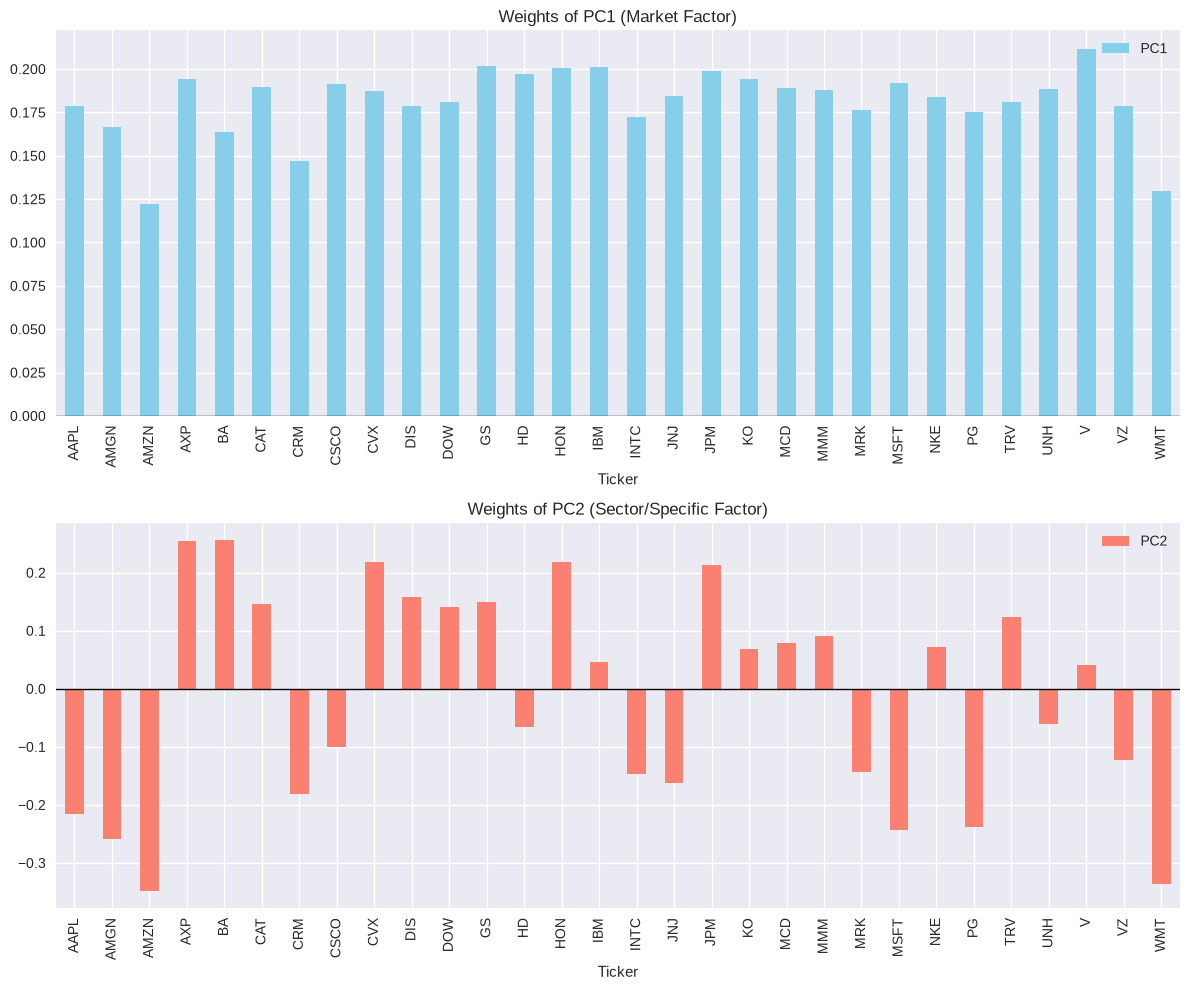

In [41]:
# Plotting PC1 and PC2 weights
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=False)

pc1 = pd.DataFrame(
    matrix_w[:, 0], 
    index=normalized_closing_prices.columns, 
    columns=['PC1']
)

pc2 = pd.DataFrame(
    matrix_w[:, 1], 
    index=normalized_closing_prices.columns, 
    columns=['PC2']
)

# Plot PC1 (Market Factor)
pc1.plot(kind='bar', ax=axes[0], color='skyblue', title='Weights of PC1 (Market Factor)')
axes[0].axhline(0, color='black', lw=1)

# Plot PC2 (Sector Rotations)
pc2.plot(kind='bar', ax=axes[1], color='salmon', title='Weights of PC2 (Sector/Specific Factor)')
axes[1].axhline(0, color='black', lw=1)

plt.tight_layout()
plt.show()

In [42]:
# 3.4 Scree Plot
explained_variance = np.real_if_close(
    np.array([pair[0] for pair in eig_pairs]) / np.sum(eig_val)
).real

for i in range(30):
    print(f"PC{i+1} Explained Variance: {explained_variance[i]:.2%}")

cumulative_variance = explained_variance.cumsum()

# Find the first index where cumulative variance is >= 0.95
agg_components_95 = np.argmax(cumulative_variance >= 0.95)

print(f"Number of components required for 95% variance: {agg_components_95}")
print(f"Total variance explained by first {agg_components_95} components: {cumulative_variance[agg_components_95]:.2%}")

PC1 Explained Variance: 61.40%
PC2 Explained Variance: 8.61%
PC3 Explained Variance: 4.45%
PC4 Explained Variance: 2.52%
PC5 Explained Variance: 2.32%
PC6 Explained Variance: 1.98%
PC7 Explained Variance: 1.79%
PC8 Explained Variance: 1.67%
PC9 Explained Variance: 1.44%
PC10 Explained Variance: 1.40%
PC11 Explained Variance: 1.15%
PC12 Explained Variance: 1.04%
PC13 Explained Variance: 0.98%
PC14 Explained Variance: 0.94%
PC15 Explained Variance: 0.86%
PC16 Explained Variance: 0.83%
PC17 Explained Variance: 0.78%
PC18 Explained Variance: 0.73%
PC19 Explained Variance: 0.67%
PC20 Explained Variance: 0.62%
PC21 Explained Variance: 0.56%
PC22 Explained Variance: 0.52%
PC23 Explained Variance: 0.47%
PC24 Explained Variance: 0.44%
PC25 Explained Variance: 0.43%
PC26 Explained Variance: 0.38%
PC27 Explained Variance: 0.31%
PC28 Explained Variance: 0.27%
PC29 Explained Variance: 0.25%
PC30 Explained Variance: 0.19%
Number of components required for 95% variance: 18
Total variance explained by

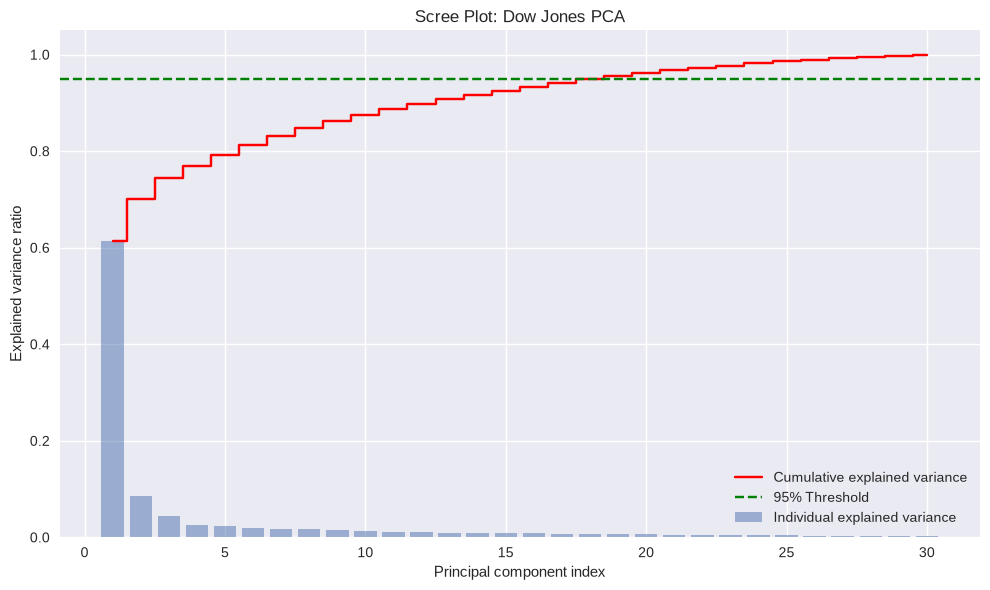

In [43]:
plt.figure(figsize=(10, 6))

# Plot individual variance (Bar chart)
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.5, 
        align='center', label='Individual explained variance')

# Plot cumulative variance (Step plot)
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid',
         label='Cumulative explained variance', color='red')

plt.axhline(y=0.95, color='g', linestyle='--', label='95% Threshold')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.title('Scree Plot: Dow Jones PCA')
plt.legend(loc='best')
plt.tight_layout()
plt.show()


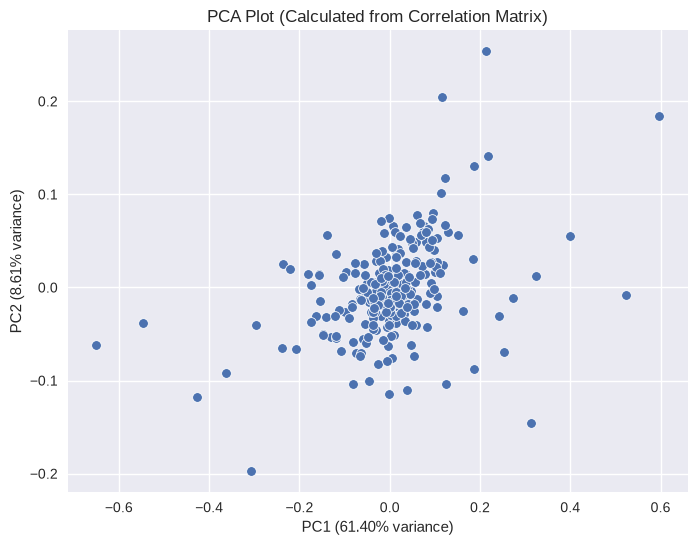

In [44]:
# Project data onto the first 2 Principal Components
pc_projection = normalized_closing_prices.dot(matrix_w[:, :2])

# Plot the result
plt.figure(figsize=(8, 6))
sns.scatterplot(x=pc_projection[0], y=pc_projection[1], palette='viridis')

plt.xlabel(f'PC1 ({explained_variance[0]:.2%} variance)')
plt.ylabel(f'PC2 ({explained_variance[1]:.2%} variance)')
plt.title('PCA Plot (Calculated from Correlation Matrix)')
plt.show()

In [45]:
# Mean of each principal component
pc_means = pc_projection.mean()
print("Mean of PC1:", pc_means[0])
print("Mean of PC2:", pc_means[1])

# Euclidean distance
euclidean_dist1 = distance.euclidean([pc_means[0]], pc_projection[0])
euclidean_dist2 = distance.euclidean([pc_means[1]], pc_projection[1])
print(f"\na) Euclidean Distance:")
print(f"   Distance1: {euclidean_dist1:.4f}")
print(f"   Distance2: {euclidean_dist2:.4f}")

# Three most distant stocks
loadings_df = pd.DataFrame(
    matrix_w[:, :2],
    index=tickers, 
    columns=['PC1_Loading', 'PC2_Loading']
)

# Find 3 most distant stocks for PC2
top_3_pc2 = loadings_df['PC2_Loading'].abs().nlargest(3).index.tolist()
print(f"3 Most Distant Stocks for PC2: {top_3_pc2}")

# Find 3 most distant stocks for PC1
top_3_pc1 = loadings_df['PC1_Loading'].abs().nlargest(3).index.tolist()
print(f"3 Most Distant Stocks for PC1: {top_3_pc1}")

Mean of PC1: 0.004389075578199729
Mean of PC2: -0.0015855071927245294

a) Euclidean Distance:
   Distance1: 1.9590
   Distance2: 0.8062
3 Most Distant Stocks for PC2: ['AMGN', 'WMT', 'AXP']
3 Most Distant Stocks for PC1: ['V', 'GS', 'IBM']
